In [8]:
!pip install numpy pandas matplotlib seaborn argparse scikit-learn

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.2 MB/s eta 0:00:00
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 86.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 53.1 MB/s eta 0:00:00:00:0100:01


In [9]:
from pathlib import Path
import os
import json
import pickle
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

try:
    import umap
    USE_UMAP = True
except ImportError:
    USE_UMAP = False
    print("UMAP not installed. Falling back to PCA.")

try:
    from datasets import Dataset
    USE_DATASETS = True
except ImportError:
    USE_DATASETS = False


def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = [start] + list(start.parents)
    
    for p in candidates:
        if (p / "data").exists() and (p / "embeddings").exists():
            return p
    
    return Path("/workspace/SemDrug")


PROJECT_ROOT = find_project_root()
print("PROJECT_ROOT:", PROJECT_ROOT)

EMB_PATH = PROJECT_ROOT / "embeddings" / "drugbank_node_embeddings_full.pkl"
NODE2ID_PATH = PROJECT_ROOT / "data" / "drugbank" / "node2id.json"

# Use the same retrieval/prompt file that you used for LLM inference.
RETRIEVAL_JSON_PATH = (
    PROJECT_ROOT
    / "prompt"
    / "drugbank"
    / "drugbank_semantic_mmr_d4_pool64_k10_mmr0.5_delta0.05_coldtop1sim0.9.json"
)

# Drug info can be json/csv depending on your preprocessing.
DRUG_INFO_CANDIDATES = [
    PROJECT_ROOT / "data" / "drugbank" / "drug_info.json",
    PROJECT_ROOT / "data" / "drugbank" / "id_to_name_mapping.csv",
    PROJECT_ROOT / "data" / "drugbank" / "drugbank_id_to_name.json",
]

OUT_DIR = PROJECT_ROOT / "visualization" / "drugbank"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("EMB_PATH:", EMB_PATH)
print("NODE2ID_PATH:", NODE2ID_PATH)
print("RETRIEVAL_JSON_PATH:", RETRIEVAL_JSON_PATH)
print("OUT_DIR:", OUT_DIR)

UMAP not installed. Falling back to PCA.
PROJECT_ROOT: /workspace/SemDrug
EMB_PATH: /workspace/SemDrug/embeddings/drugbank_node_embeddings_full.pkl
NODE2ID_PATH: /workspace/SemDrug/data/drugbank/node2id.json
RETRIEVAL_JSON_PATH: /workspace/SemDrug/prompt/drugbank/drugbank_semantic_mmr_d4_pool64_k10_mmr0.5_delta0.05_coldtop1sim0.9.json
OUT_DIR: /workspace/SemDrug/visualization/drugbank


In [10]:
def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def normalize_emb_dict_keys(emb_dict):
    """
    Convert node ids to int whenever possible.
    """
    out = {}
    for k, v in emb_dict.items():
        try:
            kk = int(k)
        except Exception:
            kk = k
        out[kk] = np.asarray(v, dtype=np.float32)
    return out


def value_to_name(value):
    """
    DrugBank drug_info sometimes stores each value as dict:
    {"name": ..., "description": ..., ...}
    """
    if isinstance(value, str):
        return value
    
    if isinstance(value, dict):
        for key in ["name", "drug_name", "label", "title"]:
            if key in value and value[key]:
                return str(value[key])
    
    return str(value)


def load_drug_name_map(candidates):
    """
    Return mapping DrugBank ID -> drug name.
    """
    for path in candidates:
        if not path.exists():
            continue
        
        print("Loading drug info from:", path)
        
        if path.suffix.lower() == ".json":
            raw = load_json(path)
            return {str(k): value_to_name(v) for k, v in raw.items()}
        
        if path.suffix.lower() == ".csv":
            df = pd.read_csv(path)
            if "drugbank_id" in df.columns and "name" in df.columns:
                return dict(zip(df["drugbank_id"].astype(str), df["name"].astype(str)))
            if "id" in df.columns and "name" in df.columns:
                return dict(zip(df["id"].astype(str), df["name"].astype(str)))
            
            print("CSV columns not recognized:", list(df.columns))
    
    print("No drug info file found. Will use DrugBank IDs as labels.")
    return {}


emb_dict = normalize_emb_dict_keys(load_pickle(EMB_PATH))

with open(NODE2ID_PATH, "r", encoding="utf-8") as f:
    node2id = json.load(f)

# node2id: DrugBank ID -> internal node ID
dbid_to_nodeid = {str(k): int(v) for k, v in node2id.items()}
nodeid_to_dbid = {int(v): str(k) for k, v in node2id.items()}

drug_name_map = load_drug_name_map(DRUG_INFO_CANDIDATES)

drug_node_ids = sorted([
    int(nid)
    for nid in emb_dict.keys()
    if int(nid) in nodeid_to_dbid
])

X_drug = np.vstack([emb_dict[nid] for nid in drug_node_ids])

print("Total embeddings:", len(emb_dict))
print("DrugBank drug nodes in embeddings:", len(drug_node_ids))
print("Embedding dim:", X_drug.shape[1])


def get_drug_dbid(node_id):
    return nodeid_to_dbid.get(int(node_id), str(node_id))


def get_drug_name(node_id):
    dbid = get_drug_dbid(node_id)
    return drug_name_map.get(str(dbid), str(dbid))


drug_meta = pd.DataFrame({
    "node_id": drug_node_ids,
    "drugbank_id": [get_drug_dbid(nid) for nid in drug_node_ids],
    "name": [get_drug_name(nid) for nid in drug_node_ids],
})

drug_meta.head()

No drug info file found. Will use DrugBank IDs as labels.
Total embeddings: 34124
DrugBank drug nodes in embeddings: 1710
Embedding dim: 768


,node_id,drugbank_id,name
0,0,DB04571,DB04571
1,1,DB00460,DB00460
2,2,DB00855,DB00855
3,3,DB09536,DB09536
4,4,DB01600,DB01600


In [13]:
# -------------------------
# Cell 3 — Load retrieval results and identify cold-start endpoint drugs
# -------------------------

import ast
import json
from pathlib import Path

import numpy as np
import pandas as pd

try:
    from datasets import Dataset
    USE_DATASETS = True
except ImportError:
    USE_DATASETS = False


def load_retrieval_table(path):
    """
    Robust loader for retrieval JSON.

    Works with:
    - HuggingFace Dataset JSON
    - JSONL, one JSON object per line
    - JSON array
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Retrieval file not found: {path}")

    if path.stat().st_size == 0:
        raise ValueError(f"Retrieval file is empty: {path}")

    if USE_DATASETS:
        try:
            return Dataset.from_json(str(path)).to_pandas()
        except Exception as e:
            print("Dataset.from_json failed, falling back to pandas:", e)

    try:
        return pd.read_json(path, lines=True)
    except ValueError:
        return pd.read_json(path)


def parse_coverage_diag(x):
    """
    coverage_diag is usually a dict, but this also handles stringified dict/json.
    """
    if isinstance(x, dict):
        return x

    if x is None or (isinstance(x, float) and np.isnan(x)):
        return {}

    if isinstance(x, str):
        x = x.strip()

        if not x:
            return {}

        try:
            return json.loads(x)
        except Exception:
            pass

        try:
            return ast.literal_eval(x)
        except Exception:
            return {}

    return {}


def expand_coverage_diag(df):
    """
    Expand coverage_diag into columns like:
    coverage_diag.d1_in_graph
    coverage_diag.d1_in_original_kg
    coverage_diag.d1_was_cold_start
    ...
    """
    out = df.copy()

    if "coverage_diag" not in out.columns:
        print("No coverage_diag column found.")
        return out

    parsed_diag = out["coverage_diag"].apply(parse_coverage_diag)
    diag_df = pd.json_normalize(parsed_diag)
    diag_df.columns = [f"coverage_diag.{c}" for c in diag_df.columns]

    out = pd.concat(
        [
            out.reset_index(drop=True),
            diag_df.reset_index(drop=True),
        ],
        axis=1,
    )

    return out


def to_bool_series(s, default=False):
    """
    Convert a pandas Series to boolean robustly.
    Handles bool, int, float, and string values.
    """
    if s is None:
        return pd.Series(default)

    def convert_one(x):
        if pd.isna(x):
            return default

        if isinstance(x, bool):
            return x

        if isinstance(x, (int, np.integer)):
            return bool(x)

        if isinstance(x, (float, np.floating)):
            return bool(int(x))

        if isinstance(x, str):
            x = x.strip().lower()
            if x in {"true", "1", "yes", "y"}:
                return True
            if x in {"false", "0", "no", "n"}:
                return False

        return default

    return s.apply(convert_one).astype(bool)


def infer_cold_start_flag(df, side):
    """
    Infer cold-start endpoint flag for one side.

    Priority:
    1. coverage_diag.d1_was_cold_start / d2_was_cold_start
    2. not coverage_diag.d1_in_original_kg / d2_in_original_kg
    3. not coverage_diag.d1_in_graph / d2_in_graph, fallback only

    Important:
    d1_in_graph may become True after adding proxy edges,
    so it should not be preferred for post-proxy files.
    """
    was_col = f"coverage_diag.{side}_was_cold_start"
    original_col = f"coverage_diag.{side}_in_original_kg"
    graph_col = f"coverage_diag.{side}_in_graph"

    if was_col in df.columns and df[was_col].notna().any():
        return to_bool_series(df[was_col], default=False)

    if original_col in df.columns and df[original_col].notna().any():
        return ~to_bool_series(df[original_col], default=True)

    if graph_col in df.columns and df[graph_col].notna().any():
        print(
            f"Warning: using {graph_col} as fallback. "
            "This may be inaccurate if the file already includes proxy edges."
        )
        return ~to_bool_series(df[graph_col], default=True)

    print(f"Warning: no coverage column found for side={side}. Assuming no cold-start.")
    return pd.Series(False, index=df.index)


# -------------------------
# Load retrieval file
# -------------------------

retrieval_df = load_retrieval_table(RETRIEVAL_JSON_PATH)
retrieval_diag = expand_coverage_diag(retrieval_df)

print("Retrieval rows:", len(retrieval_diag))
print("Columns:")
print(list(retrieval_diag.columns))

# -------------------------
# Identify cold-start endpoints
# -------------------------

required_cols = ["drug1_id", "drug2_id", "drug1_name", "drug2_name"]
missing = [c for c in required_cols if c not in retrieval_diag.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

retrieval_diag["d1_was_cold_start"] = infer_cold_start_flag(retrieval_diag, "d1")
retrieval_diag["d2_was_cold_start"] = infer_cold_start_flag(retrieval_diag, "d2")

retrieval_diag["has_cold_start_endpoint"] = (
    retrieval_diag["d1_was_cold_start"] | retrieval_diag["d2_was_cold_start"]
)

cold_start_ids_raw = set()

cold_start_ids_raw |= set(
    retrieval_diag.loc[
        retrieval_diag["d1_was_cold_start"],
        "drug1_id",
    ]
    .dropna()
    .astype(int)
)

cold_start_ids_raw |= set(
    retrieval_diag.loc[
        retrieval_diag["d2_was_cold_start"],
        "drug2_id",
    ]
    .dropna()
    .astype(int)
)

# Keep only ids that are known DrugBank drug nodes and have embeddings.
cold_start_ids = {
    int(nid)
    for nid in cold_start_ids_raw
    if int(nid) in emb_dict and int(nid) in nodeid_to_dbid
}

missing_from_embeddings = sorted([
    int(nid)
    for nid in cold_start_ids_raw
    if int(nid) not in emb_dict
])

missing_from_node2id_reverse = sorted([
    int(nid)
    for nid in cold_start_ids_raw
    if int(nid) not in nodeid_to_dbid
])

covered_ids = [
    int(nid)
    for nid in drug_node_ids
    if int(nid) not in cold_start_ids
]

print("Cold-start endpoint ids raw:", len(cold_start_ids_raw))
print("Cold-start endpoint ids with embeddings:", len(cold_start_ids))
print("KG-covered drug nodes:", len(covered_ids))

if missing_from_embeddings:
    print("Cold-start ids missing from embeddings:", missing_from_embeddings[:20])

if missing_from_node2id_reverse:
    print("Cold-start ids missing from nodeid_to_dbid:", missing_from_node2id_reverse[:20])

# -------------------------
# Summary by row
# -------------------------

print("\nCold-start row distribution:")
print(retrieval_diag["has_cold_start_endpoint"].value_counts())

print("\nEndpoint cold-start counts:")
print({
    "d1_was_cold_start": int(retrieval_diag["d1_was_cold_start"].sum()),
    "d2_was_cold_start": int(retrieval_diag["d2_was_cold_start"].sum()),
    "rows_with_any_cold_start": int(retrieval_diag["has_cold_start_endpoint"].sum()),
})

# -------------------------
# Cold-start metadata table
# -------------------------

cold_start_meta = drug_meta[
    drug_meta["node_id"].astype(int).isin(cold_start_ids)
].copy()

cold_start_meta = cold_start_meta.sort_values("name").reset_index(drop=True)

display(cold_start_meta.head(30))

# -------------------------
# Inspect rows with cold-start endpoint
# -------------------------

inspect_cols = [
    "drug1_name",
    "drug2_name",
    "drug1_id",
    "drug2_id",
    "d1_was_cold_start",
    "d2_was_cold_start",
    "coverage_diag.d1_in_graph",
    "coverage_diag.d1_in_original_kg",
    "coverage_diag.d2_in_graph",
    "coverage_diag.d2_in_original_kg",
    "path_count",
    "candidate_count",
    "retrieval_source",
    "complete_evidence",
]

inspect_cols = [c for c in inspect_cols if c in retrieval_diag.columns]

display(
    retrieval_diag.loc[
        retrieval_diag["has_cold_start_endpoint"],
        inspect_cols,
    ].head(30)
)

Retrieval rows: 31984
Columns:
['Y', 'drug1_name', 'drug2_name', 'drug1_desc', 'drug2_desc', 'drug1_db', 'drug2_db', 'drug1_id', 'drug2_id', 'label_idx', 'label', 'drug_pair', 'all_paths', 'path_str', 'raw_path_count', 'path_count', 'retrieval_source', 'complete_evidence', 'coverage_diag', 'candidate_count', 'used_leakage_safety_recovery', 'coverage_diag.d1_degree', 'coverage_diag.d1_in_graph', 'coverage_diag.d1_in_original_kg', 'coverage_diag.d1_was_cold_start', 'coverage_diag.d2_degree', 'coverage_diag.d2_in_graph', 'coverage_diag.d2_in_original_kg', 'coverage_diag.d2_was_cold_start']
Cold-start endpoint ids raw: 31
Cold-start endpoint ids with embeddings: 31
KG-covered drug nodes: 1679

Cold-start row distribution:
has_cold_start_endpoint
False    27997
True      3987
Name: count, dtype: int64

Endpoint cold-start counts:
{'d1_was_cold_start': 2141, 'd2_was_cold_start': 1846, 'rows_with_any_cold_start': 3987}


,node_id,drugbank_id,name
0,1429,DB06264,DB06264
1,168,DB06403,DB06403
2,950,DB06690,DB06690
3,1534,DB06767,DB06767
4,1056,DB06826,DB06826
5,771,DB08814,DB08814
6,1602,DB09021,DB09021
7,1258,DB09034,DB09034
8,1140,DB09041,DB09041
9,1199,DB09053,DB09053


,drug1_name,drug2_name,drug1_id,drug2_id,d1_was_cold_start,d2_was_cold_start,coverage_diag.d1_in_graph,coverage_diag.d1_in_original_kg,coverage_diag.d2_in_graph,coverage_diag.d2_in_original_kg,path_count,candidate_count,retrieval_source,complete_evidence
69,Carbamazepine,Enalaprilat,156,617,False,True,True,True,True,False,10,64,semantic_mmr_reranked_paths,True
70,Lumacaftor,Amlodipine,263,385,True,False,True,False,True,True,10,64,semantic_mmr_reranked_paths,True
71,Lumacaftor,Tiotropium,263,26,True,False,True,False,True,True,10,64,semantic_mmr_reranked_paths,True
77,Fosphenytoin,Troleandomycin,150,436,False,True,True,True,True,False,10,64,semantic_mmr_reranked_paths,True
79,Lumacaftor,Oxazepam,263,229,True,False,True,False,True,True,10,64,semantic_mmr_reranked_paths,True
80,Lumacaftor,Cholecalciferol,263,414,True,False,True,False,True,True,10,64,semantic_mmr_reranked_paths,True
82,Carbamazepine,Ambrisentan,156,168,False,True,True,True,True,False,10,64,semantic_mmr_reranked_paths,True
96,Lumacaftor,Oxycodone,263,163,True,False,True,False,True,True,10,64,semantic_mmr_reranked_paths,True
99,Lumacaftor,Ethosuximide,263,572,True,False,True,False,True,True,10,64,semantic_mmr_reranked_paths,True
105,Lumacaftor,Felodipine,263,516,True,False,True,False,True,True,10,64,semantic_mmr_reranked_paths,True


In [14]:
def reduce_2d(X, method="umap", random_state=42):
    if method == "umap" and USE_UMAP:
        reducer = umap.UMAP(
            n_neighbors=15,
            min_dist=0.2,
            metric="cosine",
            random_state=random_state,
        )
        Z = reducer.fit_transform(X)
        title = "UMAP projection"
    else:
        reducer = PCA(n_components=2, random_state=random_state)
        Z = reducer.fit_transform(X)
        title = "PCA projection"
    
    return Z, title


method = "umap" if USE_UMAP else "pca"
Z_drug, title_prefix = reduce_2d(X_drug, method=method)

plot_df = drug_meta.copy()
plot_df["x"] = Z_drug[:, 0]
plot_df["y"] = Z_drug[:, 1]
plot_df["is_cold_start"] = plot_df["node_id"].isin(cold_start_ids)

plot_df.head()

,node_id,drugbank_id,name,x,y,is_cold_start
0,0,DB04571,DB04571,0.044728,-0.053692,False
1,1,DB00460,DB00460,0.020162,-0.023967,False
2,2,DB00855,DB00855,0.064711,-0.116170,False
3,3,DB09536,DB09536,0.034490,-0.084200,False
4,4,DB01600,DB01600,0.029906,0.047972,False


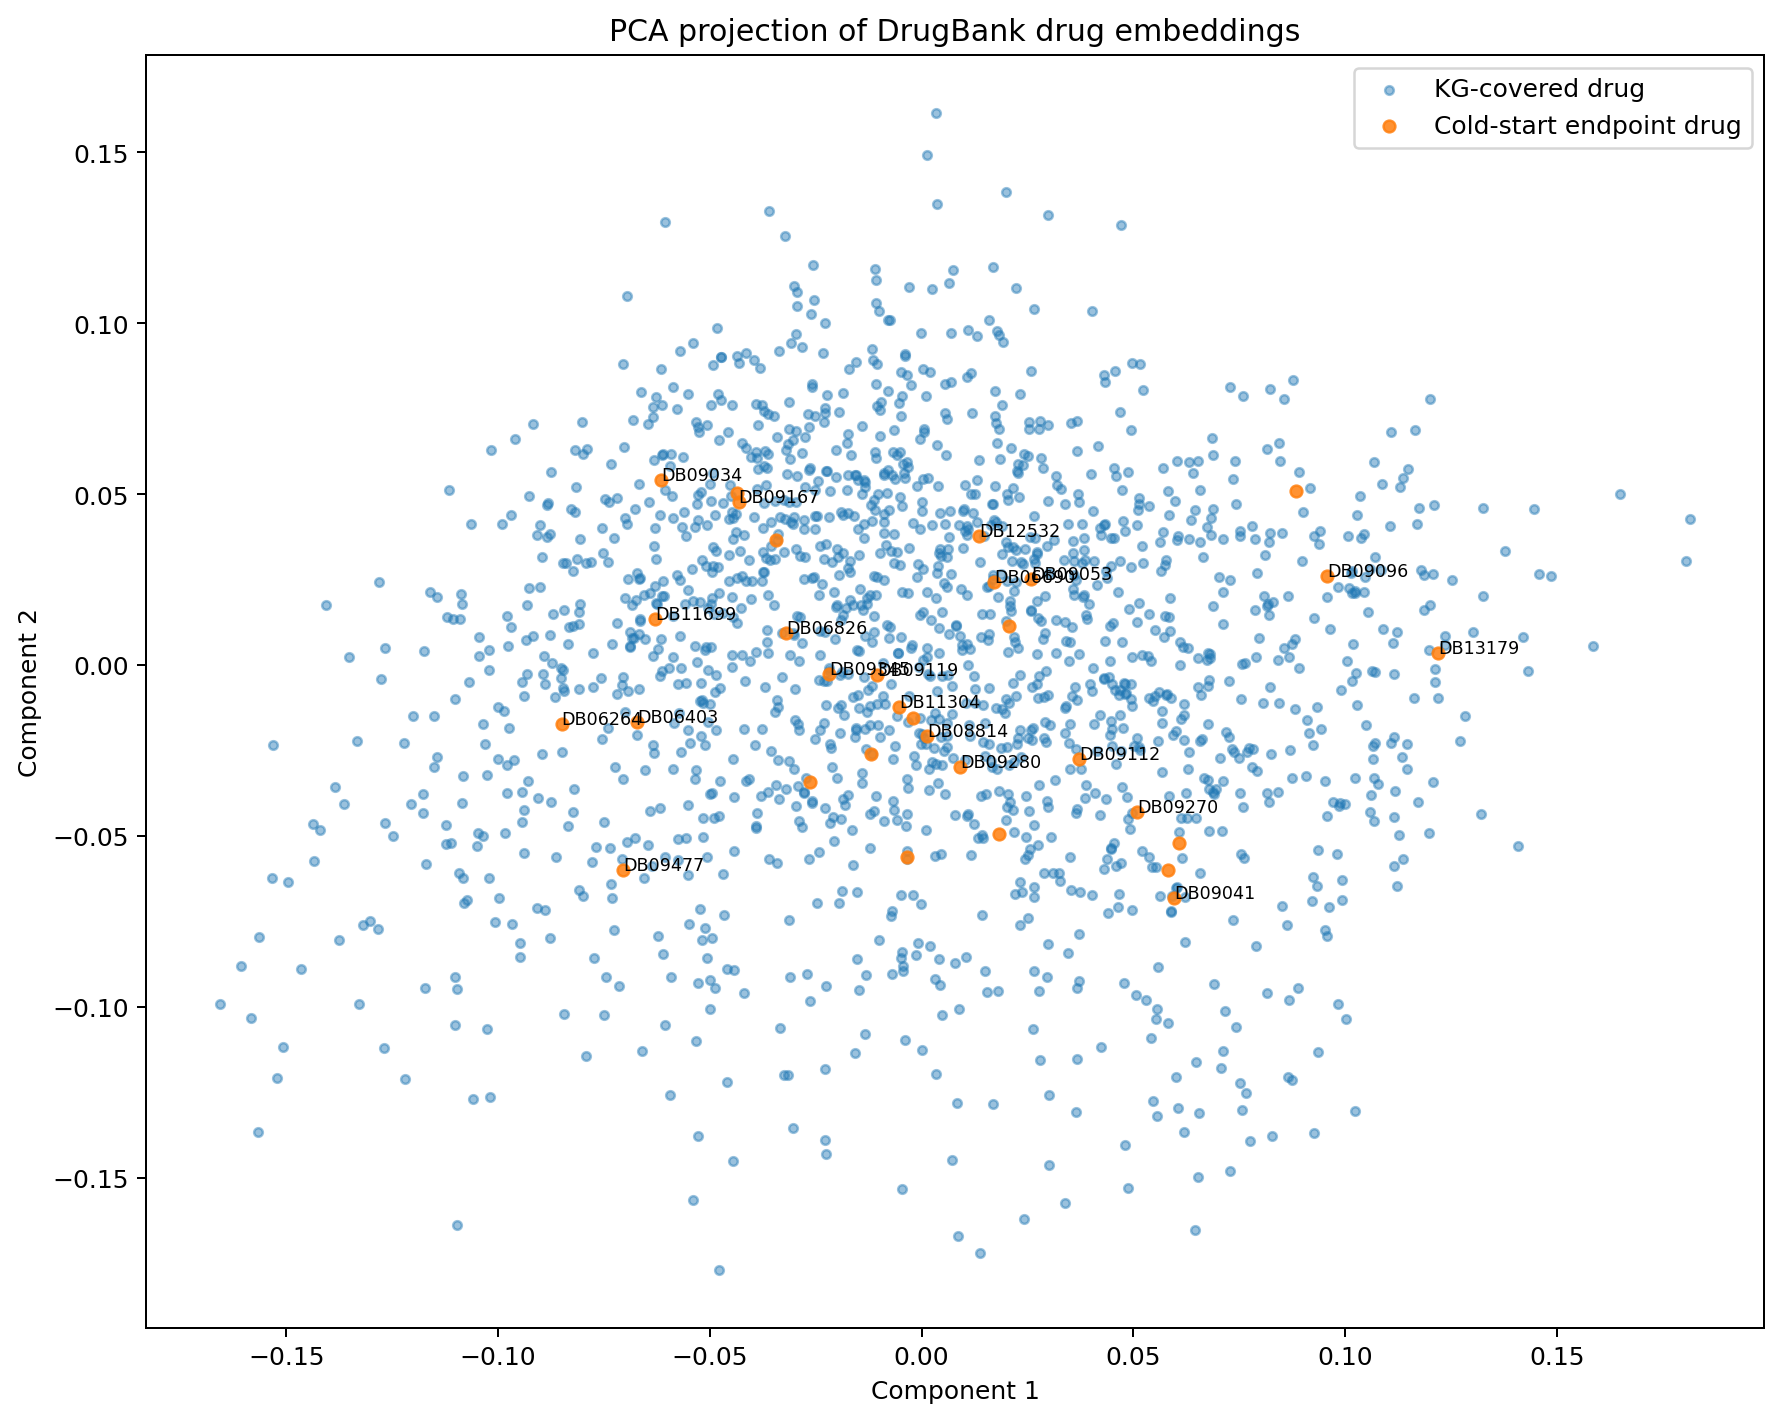

Saved: /workspace/SemDrug/visualization/drugbank/drugbank_pca_cold_start_projection.png


In [15]:
plt.figure(figsize=(10, 8), dpi=180)

normal = plot_df[~plot_df["is_cold_start"]]
cold = plot_df[plot_df["is_cold_start"]]

plt.scatter(
    normal["x"],
    normal["y"],
    s=12,
    alpha=0.45,
    label="KG-covered drug",
)

plt.scatter(
    cold["x"],
    cold["y"],
    s=22,
    alpha=0.85,
    label="Cold-start endpoint drug",
)

# Annotate a small number of cold-start drugs.
for _, row in cold.head(20).iterrows():
    plt.text(row["x"], row["y"], row["name"], fontsize=7)

plt.title(f"{title_prefix} of DrugBank drug embeddings")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(frameon=True)
plt.tight_layout()

out_path = OUT_DIR / f"drugbank_{method}_cold_start_projection.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [16]:
def l2_normalize(X, eps=1e-12):
    norm = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norm, eps)


def sample_pairwise_cosine(X, n_pairs=100_000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(X)
    Xn = l2_normalize(X)
    
    i = rng.integers(0, n, size=n_pairs)
    j = rng.integers(0, n, size=n_pairs)
    
    mask = i != j
    i = i[mask]
    j = j[mask]
    
    sims = np.sum(Xn[i] * Xn[j], axis=1)
    return sims


pair_sims = sample_pairwise_cosine(X_drug, n_pairs=100_000, seed=42)
pair_dist = 1.0 - pair_sims

pd.Series(pair_sims).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    99939.000000
mean         0.914066
std          0.016151
min          0.807695
1%           0.860380
5%           0.886899
50%          0.915507
95%          0.937075
99%          0.946557
max          1.000000
dtype: float64

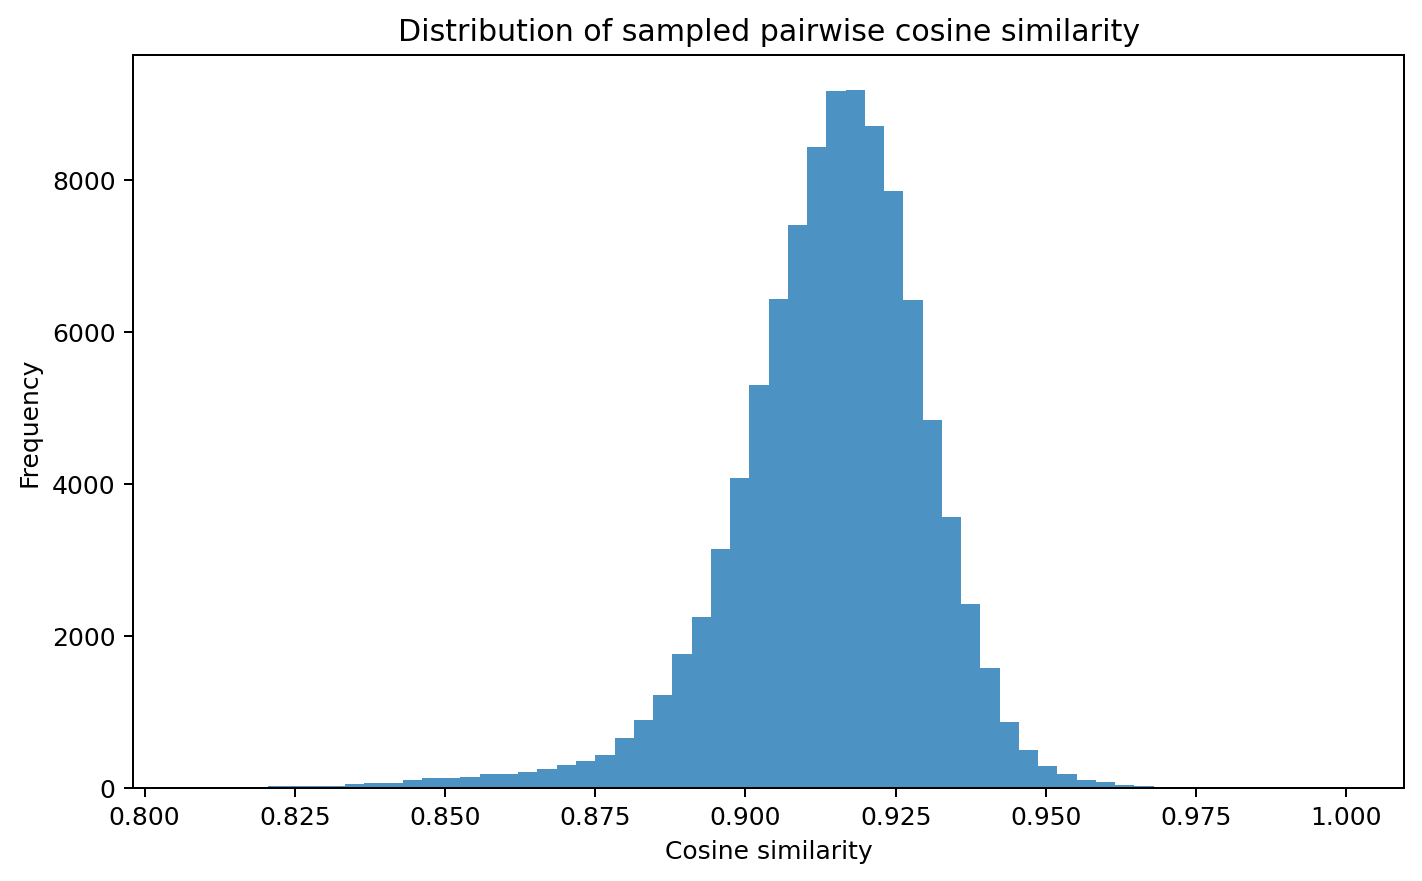

Saved: /workspace/SemDrug/visualization/drugbank/drugbank_pairwise_cosine_similarity_distribution.png


In [17]:
plt.figure(figsize=(8, 5), dpi=180)
plt.hist(pair_sims, bins=60, alpha=0.8)
plt.title("Distribution of sampled pairwise cosine similarity")
plt.xlabel("Cosine similarity")
plt.ylabel("Frequency")
plt.tight_layout()

out_path = OUT_DIR / "drugbank_pairwise_cosine_similarity_distribution.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [18]:
def nearest_neighbor_similarity_all(X, ids, chunk_size=512):
    """
    For each vector, find nearest neighbor cosine similarity excluding itself.
    Chunked to avoid huge memory spikes.
    """
    Xn = l2_normalize(X)
    n = len(Xn)
    
    best_sims = np.full(n, -np.inf, dtype=np.float32)
    best_indices = np.full(n, -1, dtype=np.int64)
    
    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        sims = Xn[start:end] @ Xn.T
        
        # Exclude self.
        for local_i, global_i in enumerate(range(start, end)):
            sims[local_i, global_i] = -np.inf
        
        idx = np.argmax(sims, axis=1)
        val = sims[np.arange(end - start), idx]
        
        best_sims[start:end] = val
        best_indices[start:end] = idx
    
    result = pd.DataFrame({
        "node_id": ids,
        "drugbank_id": [get_drug_dbid(nid) for nid in ids],
        "name": [get_drug_name(nid) for nid in ids],
        "nearest_node_id": [ids[i] for i in best_indices],
        "nearest_drugbank_id": [get_drug_dbid(ids[i]) for i in best_indices],
        "nearest_name": [get_drug_name(ids[i]) for i in best_indices],
        "nearest_cosine_similarity": best_sims,
        "nearest_cosine_distance": 1.0 - best_sims,
    })
    
    return result


nn_df = nearest_neighbor_similarity_all(X_drug, drug_node_ids, chunk_size=512)
nn_df.to_csv(OUT_DIR / "drugbank_nearest_neighbor_similarity.csv", index=False)

nn_df.sort_values("nearest_cosine_similarity", ascending=False).head(20)

,node_id,drugbank_id,name,nearest_node_id,nearest_drugbank_id,nearest_name,nearest_cosine_similarity,nearest_cosine_distance
469,469,DB00647,DB00647,325,DB09396,DB09396,1.000000,-1.192093e-07
325,325,DB09396,DB09396,469,DB00647,DB00647,1.000000,-1.192093e-07
873,873,DB09323,DB09323,881,DB01053,DB01053,0.996248,3.752053e-03
881,881,DB01053,DB01053,873,DB09323,DB09323,0.996248,3.752053e-03
1497,1497,DB01764,DB01764,1508,DB01369,DB01369,0.995673,4.327238e-03
1508,1508,DB01369,DB01369,1497,DB01764,DB01764,0.995673,4.327238e-03
1467,1467,DB11596,DB11596,1523,DB00650,DB00650,0.994836,5.164027e-03
1523,1523,DB00650,DB00650,1467,DB11596,DB11596,0.994836,5.164027e-03
130,130,DB01222,DB01222,104,DB00596,DB00596,0.991159,8.840501e-03
104,104,DB00596,DB00596,130,DB01222,DB01222,0.991159,8.840501e-03


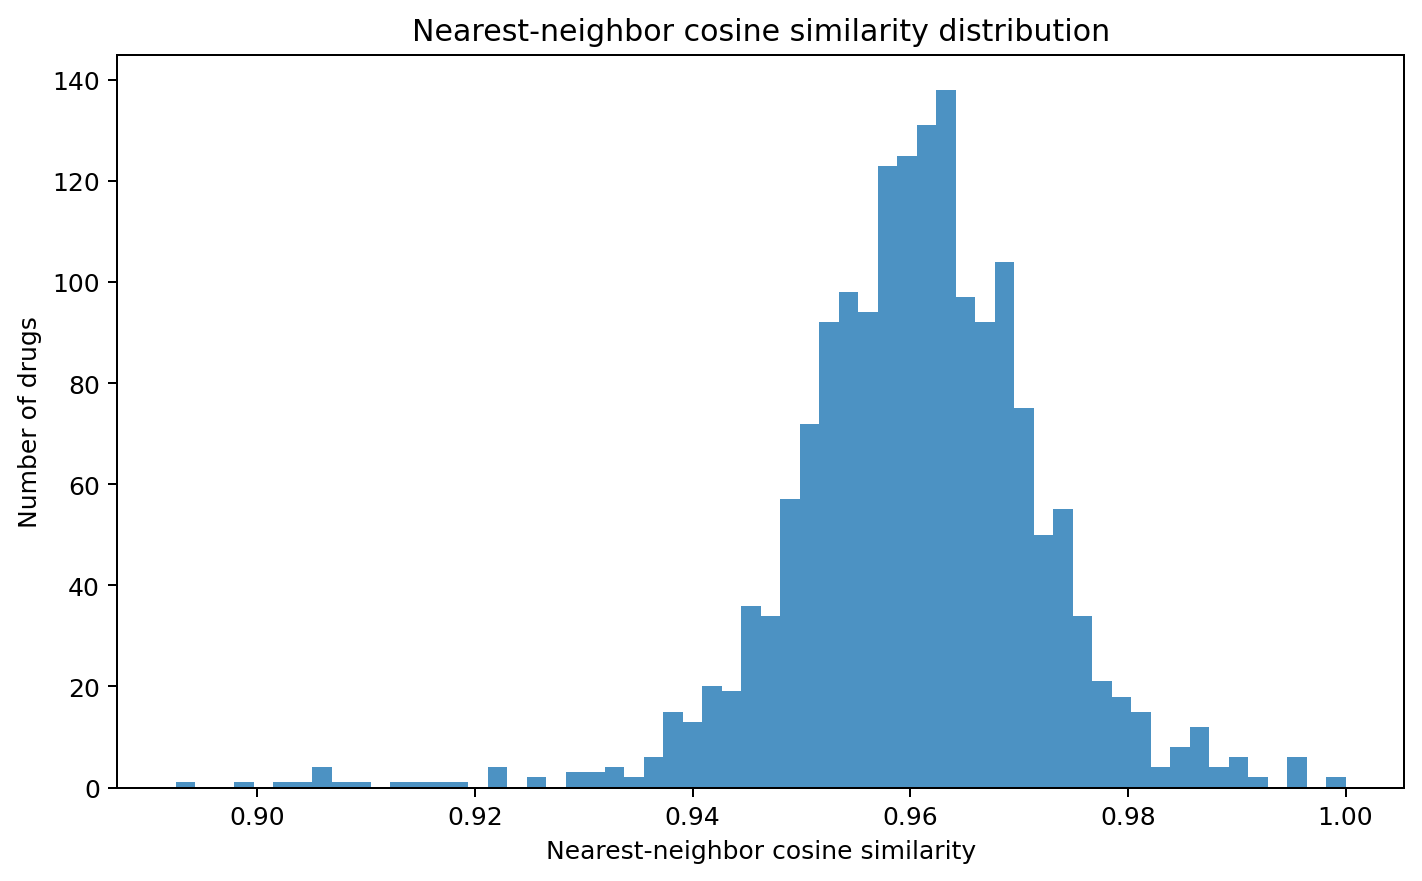

Saved: /workspace/SemDrug/visualization/drugbank/drugbank_nearest_neighbor_similarity_distribution.png


In [19]:
plt.figure(figsize=(8, 5), dpi=180)
plt.hist(nn_df["nearest_cosine_similarity"], bins=60, alpha=0.8)
plt.title("Nearest-neighbor cosine similarity distribution")
plt.xlabel("Nearest-neighbor cosine similarity")
plt.ylabel("Number of drugs")
plt.tight_layout()

out_path = OUT_DIR / "drugbank_nearest_neighbor_similarity_distribution.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [20]:
def compute_topk_proxies(cold_ids, covered_ids, emb_dict, top_k=10, chunk_size=128):
    cold_ids = list(sorted(cold_ids))
    covered_ids = list(sorted(covered_ids))
    
    if len(cold_ids) == 0:
        print("No cold-start ids found.")
        return pd.DataFrame()
    
    X_cold = np.vstack([emb_dict[nid] for nid in cold_ids])
    X_cov = np.vstack([emb_dict[nid] for nid in covered_ids])
    
    X_cold_n = l2_normalize(X_cold)
    X_cov_n = l2_normalize(X_cov)
    
    rows = []
    
    for start in range(0, len(cold_ids), chunk_size):
        end = min(start + chunk_size, len(cold_ids))
        sims = X_cold_n[start:end] @ X_cov_n.T
        
        k = min(top_k, len(covered_ids))
        top_idx_unsorted = np.argpartition(-sims, kth=k-1, axis=1)[:, :k]
        
        for local_i, cold_pos in enumerate(range(start, end)):
            candidate_idx = top_idx_unsorted[local_i]
            candidate_sims = sims[local_i, candidate_idx]
            order = np.argsort(-candidate_sims)
            
            cold_node_id = cold_ids[cold_pos]
            
            for rank, ord_i in enumerate(order, start=1):
                proxy_pos = candidate_idx[ord_i]
                proxy_node_id = covered_ids[proxy_pos]
                sim = float(sims[local_i, proxy_pos])
                
                rows.append({
                    "cold_start_node_id": cold_node_id,
                    "cold_start_drugbank_id": get_drug_dbid(cold_node_id),
                    "cold_start_name": get_drug_name(cold_node_id),
                    "rank": rank,
                    "proxy_node_id": proxy_node_id,
                    "proxy_drugbank_id": get_drug_dbid(proxy_node_id),
                    "proxy_name": get_drug_name(proxy_node_id),
                    "cosine_similarity": sim,
                    "cosine_distance": 1.0 - sim,
                })
    
    return pd.DataFrame(rows)


neighbors = compute_topk_proxies(
    cold_ids=cold_start_ids,
    covered_ids=covered_ids,
    emb_dict=emb_dict,
    top_k=10,
)

neighbors.to_csv(OUT_DIR / "drugbank_cold_start_top10_proxies.csv", index=False)

print("Rows:", len(neighbors))
neighbors.head(30)

Rows: 310


,cold_start_node_id,cold_start_drugbank_id,cold_start_name,rank,proxy_node_id,proxy_drugbank_id,proxy_name,cosine_similarity,cosine_distance
0,168,DB06403,DB06403,1,1040,DB00820,DB00820,0.960977,0.039023
1,168,DB06403,DB06403,2,225,DB00559,DB00559,0.960840,0.039160
2,168,DB06403,DB06403,3,1068,DB08932,DB08932,0.955907,0.044093
3,168,DB06403,DB06403,4,306,DB09026,DB09026,0.955077,0.044923
4,168,DB06403,DB06403,5,315,DB00584,DB00584,0.954257,0.045743
5,168,DB06403,DB06403,6,1052,DB00692,DB00692,0.952322,0.047678
6,168,DB06403,DB06403,7,1071,DB00966,DB00966,0.951742,0.048258
7,168,DB06403,DB06403,8,691,DB00790,DB00790,0.949844,0.050156
8,168,DB06403,DB06403,9,1352,DB09292,DB09292,0.949615,0.050385
9,168,DB06403,DB06403,10,239,DB00177,DB00177,0.949421,0.050579


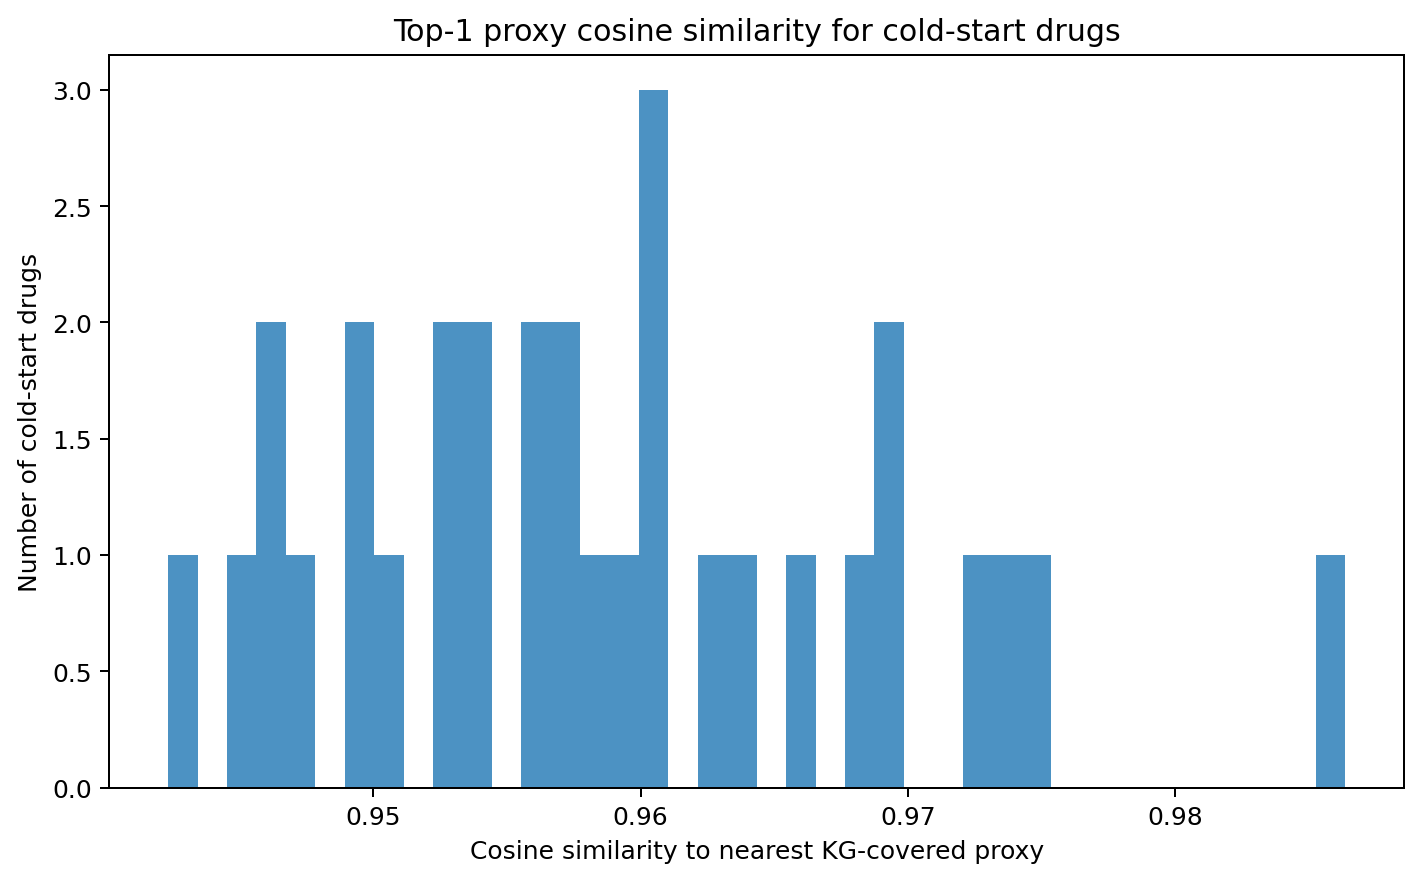

Saved: /workspace/SemDrug/visualization/drugbank/drugbank_cold_start_top1_proxy_similarity_distribution.png


,cold_start_node_id,cold_start_drugbank_id,cold_start_name,rank,proxy_node_id,proxy_drugbank_id,proxy_name,cosine_similarity,cosine_distance
40,617,DB09477,DB09477,1,315,DB00584,DB00584,0.986349,0.013651
290,1661,DB13879,DB13879,1,1113,DB08873,DB08873,0.974595,0.025405
160,1356,DB09112,DB09112,1,1619,DB09499,DB09499,0.974121,0.025879
170,1377,DB11699,DB11699,1,383,DB00889,DB00889,0.972642,0.027358
10,263,DB09280,DB09280,1,1465,DB08820,DB08820,0.969331,0.030669
140,1199,DB09053,DB09053,1,1240,DB06616,DB06616,0.968978,0.031022
280,1658,DB13878,DB13878,1,212,DB09297,DB09297,0.968680,0.031320
270,1602,DB09021,DB09021,1,393,DB00475,DB00475,0.966277,0.033723
240,1546,DB09156,DB09156,1,1527,DB01249,DB01249,0.963985,0.036015
60,771,DB08814,DB08814,1,1178,DB00432,DB00432,0.963115,0.036885


In [21]:
top1 = neighbors[neighbors["rank"] == 1].copy()

plt.figure(figsize=(8, 5), dpi=180)
plt.hist(top1["cosine_similarity"], bins=40, alpha=0.8)
plt.title("Top-1 proxy cosine similarity for cold-start drugs")
plt.xlabel("Cosine similarity to nearest KG-covered proxy")
plt.ylabel("Number of cold-start drugs")
plt.tight_layout()

out_path = OUT_DIR / "drugbank_cold_start_top1_proxy_similarity_distribution.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

top1.sort_values("cosine_similarity", ascending=False).head(20)

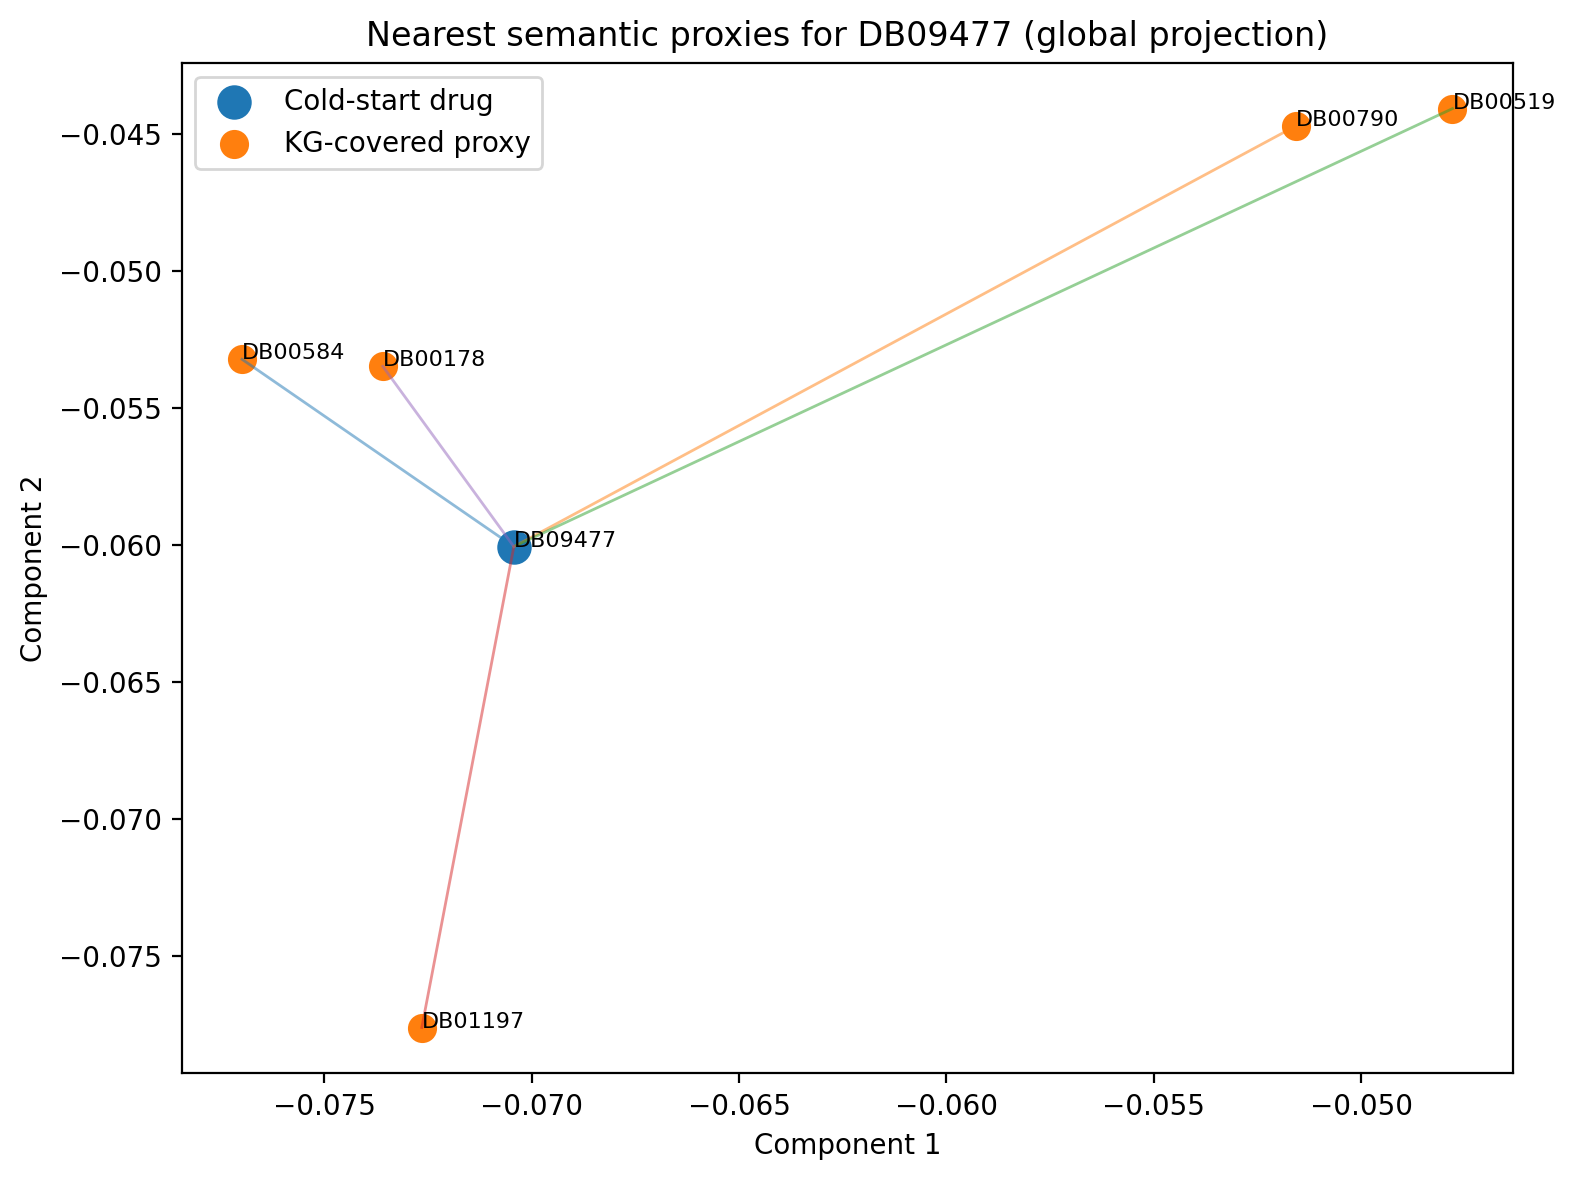

Saved: /workspace/SemDrug/visualization/drugbank/drugbank_proxy_case_DB09477.png


,cold_start_node_id,cold_start_drugbank_id,cold_start_name,rank,proxy_node_id,proxy_drugbank_id,proxy_name,cosine_similarity,cosine_distance
40,617,DB09477,DB09477,1,315,DB00584,DB00584,0.986349,0.013651
41,617,DB09477,DB09477,2,691,DB00790,DB00790,0.970849,0.029151
42,617,DB09477,DB09477,3,445,DB00519,DB00519,0.969884,0.030116
43,617,DB09477,DB09477,4,669,DB01197,DB01197,0.966062,0.033938
44,617,DB09477,DB09477,5,607,DB00178,DB00178,0.964525,0.035475


In [22]:
def plot_proxy_case(cold_start_node_id=None, top_k=5, use_global_projection=True):
    if neighbors.empty:
        raise ValueError("neighbors is empty. Run proxy computation first.")
    
    if cold_start_node_id is None:
        # Pick the cold-start drug with highest top-1 similarity.
        cold_start_node_id = int(
            neighbors[neighbors["rank"] == 1]
            .sort_values("cosine_similarity", ascending=False)
            .iloc[0]["cold_start_node_id"]
        )
    
    case_df = neighbors[
        neighbors["cold_start_node_id"].astype(int) == int(cold_start_node_id)
    ].sort_values("rank").head(top_k)
    
    if case_df.empty:
        raise ValueError(f"No proxy rows found for cold_start_node_id={cold_start_node_id}")
    
    selected_ids = [int(cold_start_node_id)] + list(case_df["proxy_node_id"].astype(int))
    selected_names = [get_drug_name(nid) for nid in selected_ids]
    
    if use_global_projection:
        coord_map = dict(zip(plot_df["node_id"].astype(int), zip(plot_df["x"], plot_df["y"])))
        Z_case = np.array([coord_map[nid] for nid in selected_ids])
        title_suffix = "global projection"
    else:
        X_case = np.vstack([emb_dict[nid] for nid in selected_ids])
        Z_case = PCA(n_components=2, random_state=42).fit_transform(X_case)
        title_suffix = "local PCA"
    
    plt.figure(figsize=(8, 6), dpi=200)
    
    # Cold-start point.
    plt.scatter(Z_case[0, 0], Z_case[0, 1], s=130, label="Cold-start drug")
    
    # Proxy points.
    plt.scatter(Z_case[1:, 0], Z_case[1:, 1], s=90, label="KG-covered proxy")
    
    # Draw lines.
    for i in range(1, len(selected_ids)):
        plt.plot(
            [Z_case[0, 0], Z_case[i, 0]],
            [Z_case[0, 1], Z_case[i, 1]],
            linewidth=1,
            alpha=0.5,
        )
    
    for i, name in enumerate(selected_names):
        plt.text(Z_case[i, 0], Z_case[i, 1], name, fontsize=8)
    
    cold_name = selected_names[0]
    plt.title(f"Nearest semantic proxies for {cold_name} ({title_suffix})")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend()
    plt.tight_layout()
    
    safe_name = "".join(c if c.isalnum() or c in "-_" else "_" for c in cold_name)
    out_path = OUT_DIR / f"drugbank_proxy_case_{safe_name}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved:", out_path)
    display(case_df)
    
    return case_df


case_df = plot_proxy_case(cold_start_node_id=None, top_k=5, use_global_projection=True)